In [ ]:
import math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots
import os
import skimage.transform as skimt

In [12]:
test_samples_dir = Path(f"/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples")
test_samples = np.load(os.path.join(test_samples_dir, "sxr_samples_with_background_coarse.npy"))
test_samples_psis = np.load(os.path.join(test_samples_dir, "psis_coarse.npy"))
print(test_samples.shape)

(1000, 120, 40)


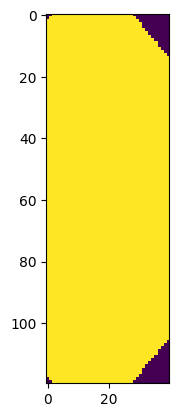

In [108]:
tcv_mask = np.load("/home/fusiontomo/Repos/diffusion_tomography/reaction_diffusion/routines/tcv_mask_1_subpixels_NINO.npy")
tcv_mask = skimt.resize(tcv_mask, (120, 40), anti_aliasing=False, mode='edge')
tcv_mask[tcv_mask>0]=1
plt.imshow(tcv_mask)

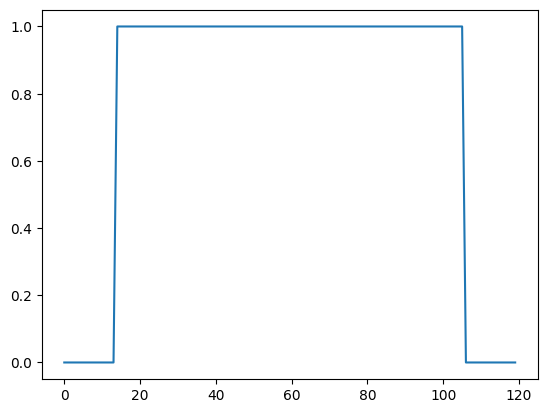

In [109]:
plt.plot(tcv_mask[:,-1])

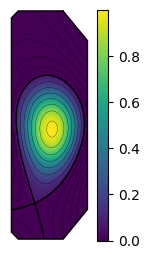

In [31]:
test_idx = 100

tomo_plots.plot_profile(test_samples[test_idx,:,:], tcv_plot_clip=True, contour_image=test_samples_psis[test_idx,:,:],
                            cmap="viridis", ax=None, colorbar=True, contour_color="k", vmin=None, vmax=None, aspect=None, lcfs_width=1, lwidth=0.2)

In [ ]:
train_samples_dir = Path(f'../../data/sxr_data/sxr_profiles_coarse')
train_samples = np.zeros((1000,120,40))
for idx_tr in range(train_samples.shape[0]):
    train_samples[idx_tr, :, :] = np.load(os.path.join(train_samples_dir, f"sxr_sample_{idx_tr}.npy"))

In [35]:
train_samples.shape

(1000, 120, 40)

In [36]:
forward_model = np.load(("forward_model/forward_model_sxr_full_geometry.npy"))

In [83]:
forward_model = sp.csr_matrix(forward_model)
forward_model

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 37770 stored elements and shape (100, 4800)>

In [89]:
forward_model.nnz / (4800*100)

0.0786875

In [112]:
21*100/(60)

35.0

In [113]:

np.logspace(-1, 3, 13)

array([1.00000000e-01, 2.15443469e-01, 4.64158883e-01, 1.00000000e+00,
       2.15443469e+00, 4.64158883e+00, 1.00000000e+01, 2.15443469e+01,
       4.64158883e+01, 1.00000000e+02, 2.15443469e+02, 4.64158883e+02,
       1.00000000e+03])

In [87]:
forward_model.nnz

37770

In [38]:
train_data = forward_model @ train_samples.reshape(train_samples.shape[0], -1).T
test_data = forward_model @ test_samples.reshape(test_samples.shape[0], -1).T

In [41]:
print(np.mean(train_data), np.mean(test_data))

6.958439916110972e-10 7.019809508095538e-10


In [47]:
sigma_noise = 0.05 * np.mean(train_data)


noisy_data = train_data + sigma_noise * np.random.randn(*train_data.shape)

In [93]:
sigma_noise

np.float64(3.4792199580554864e-11)

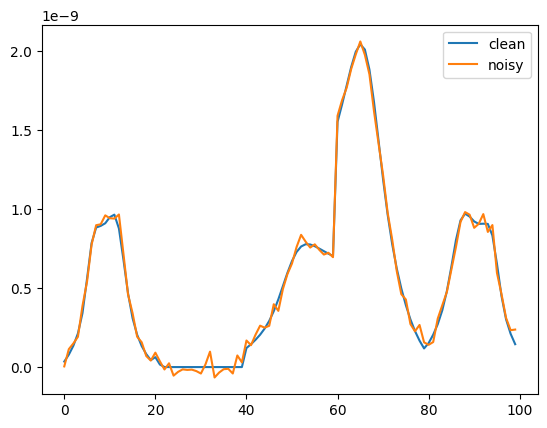

In [57]:
iid=5
plt.plot(train_data[:,iid], label="clean")
plt.plot(noisy_data[:,iid], label="noisy")
plt.legend()

In [75]:
sigma_noise_recon = 0.02

normalized_data_test = test_data / np.max(test_data.reshape(test_data.shape[0], -1), axis=0, keepdims=True)

noisy_data_test = normalized_data_test + sigma_noise_recon * np.random.randn(*normalized_data_test.shape)

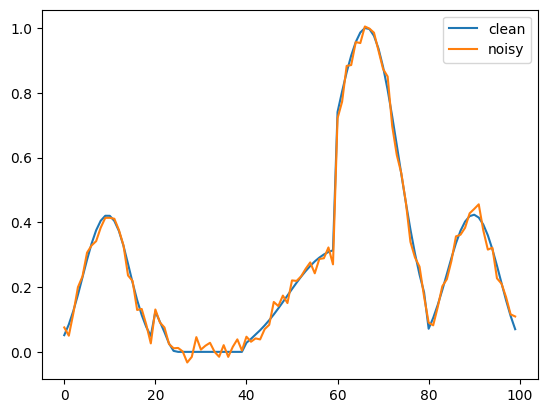

In [78]:
iid=100
plt.plot(normalized_data_test[:,iid], label="clean")
plt.plot(noisy_data_test[:,iid], label="noisy")
plt.legend()

In [82]:
import reaction_diffusion.routines.tomo_fusion.tools.helpers as tomo_helps
import reaction_diffusion.routines.tomo_fusion.functionals_definition as fct_def
import reaction_diffusion.routines.tomo_fusion.hyperparameter_tuning as hyper_tune
import reaction_diffusion.routines.tomo_fusion.bayesian_computations as bcomp

In [1]:
best_hyper = np.load("reaction_diffusion/phantom_studies/tuning_data/reg_param_tuning_sigma002/best_hyperparams.npy", allow_pickle=True)

NameError: name 'np' is not defined

In [119]:
nb_occurrences = np.load("reaction_diffusion/phantom_studies/tuning_data/reg_param_tuning_sigma002/nb_occurrences.npy", allow_pickle=True)

In [115]:
best_hyper.shape

(100,)

(array([71.,  0., 17.,  0.,  7.,  0.,  0.,  0.,  0.,  5.]),
 array([  0.46415888,  21.9620899 ,  43.46002091,  64.95795192,
         86.45588293, 107.95381394, 129.45174496, 150.94967597,
        172.44760698, 193.94553799, 215.443469  ]),
 <BarContainer object of 10 artists>)

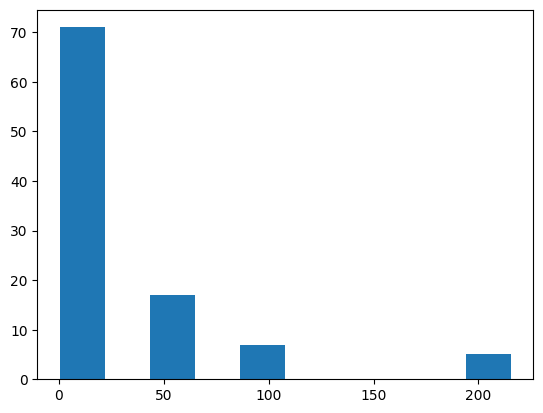

In [ ]:

plt.hist(best_hyper)

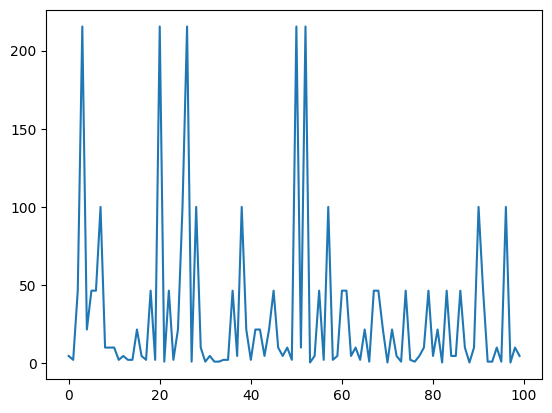

In [117]:
plt.plot(best_hyper)

In [118]:
np.mean(best_hyper)

np.float64(30.53177998738709)

<Figure size 640x480 with 0 Axes>

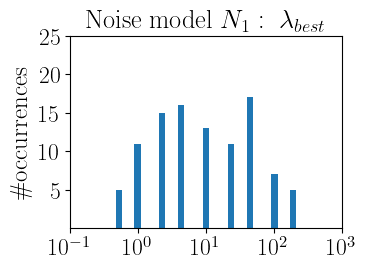

In [136]:
plt.figure()

plt.figure(figsize=(3.5,2.5))
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
})


vec = np.zeros(100)
counter=0
for i in range(13):
    vec[counter:counter+int(nb_occurrences[i])] = i
    counter += int(nb_occurrences[i])

plt.hist(vec, bins=29)
plt.xticks([0,3,6,9,12], [r"$10^{-1}$", r"$10^{0}$", r"$10^{1}$", r"$10^{2}$", r"$10^{3}$"], fontsize=17)
plt.yticks([5,10,15,20,25], fontsize=17) 
plt.title(r"$\mathrm{Noise \;model \;}N_1:\;\lambda_{best}$", fontsize=19)

plt.ylabel(r"$\# \mathrm{occurrences}$", fontsize=18, labelpad=5)

plt.show()